# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
print(df.duplicated().sum());
clean=df.drop_duplicates().copy()

clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names



720


In [4]:
print(clean["msrp"].value_counts().sum())

clean.loc[clean['msrp']==2000,'msrp']=np.nan

11194


In [5]:
clean[clean["engine_fuel_type"]=="electric"][
["make","model","city_mpg","highway_mpg"]]

clean["is_electric"]=clean["engine_fuel_type"]=="electric"


In [6]:
print(clean["highway_mpg"].max())

clean[clean["highway_mpg"]>150][
["make","model","city_mpg","highway_mpg"]]

clean.loc[clean["highway_mpg"]==354,"highway_mpg"]=np.nan

354


In [7]:
print(clean.isna().sum())

clean[clean["engine_hp"].isna()][
["make","model","year","engine_fuel_type","engine_hp"]].head(20)

make                   0
model                  0
year                   0
engine_fuel_type       3
engine_hp             69
engine_cylinders      30
transmission_type      0
driven_wheels          0
number_of_doors        6
vehicle_size           0
vehicle_style          0
highway_mpg            1
city_mpg               0
popularity             0
msrp                 747
is_electric            0
dtype: int64


,make,model,year,engine_fuel_type,engine_hp
539,FIAT,500e,2015,electric,NaN
540,FIAT,500e,2016,electric,NaN
541,FIAT,500e,2017,electric,NaN
2905,Lincoln,Continental,2017,premium unleaded (recommended),NaN
2906,Lincoln,Continental,2017,premium unleaded (recommended),NaN
2907,Lincoln,Continental,2017,premium unleaded (recommended),NaN
2908,Lincoln,Continental,2017,premium unleaded (recommended),NaN
4203,Ford,Escape,2017,regular unleaded,NaN
4204,Ford,Escape,2017,regular unleaded,NaN
4205,Ford,Escape,2017,regular unleaded,NaN


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | There are duplicated rows. | .duplicate()| 720| Deleted them | They are duplicates.
| 2 |The most common value | .value_counts() |11914 | Changed the values to NaN. | Did not want to delete the entire row. |
| 3 | Not all the same units| electric cars vs gasoline cars |electric cars | Adds a column for electric cars | so we know the difference |
| 4 | the value of MPG seemed too high | .max() | a few | changed the 354 value to NaN | seemed like a data entry error |
| 5 | lots of missing values | .isna() | a couple | flagged and left it | shouldn't make up values |

In [8]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 16)
engine_fuel_type      3
engine_hp            69
engine_cylinders     30
number_of_doors       6
highway_mpg           1
msrp                747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

44788.66689001627
31870.0


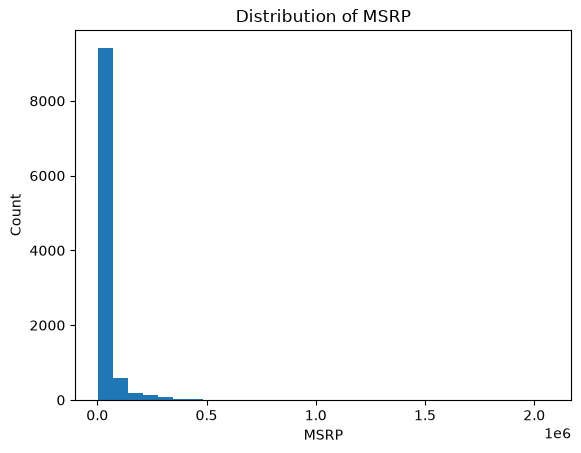

24.447209725279983


In [9]:
# a) mean and median
msrp=clean["msrp"].dropna()
mean_price=msrp.mean();
median_price=msrp.median();
prices=clean["msrp"].dropna();

print(mean_price);
print(median_price);
#The mean is bigger because the distribution is right skewed. 

# b) two histograms side by side (plt.subplots(1, 2))
plt.hist(prices,bins=30);
plt.xlabel("MSRP");
plt.ylabel("Count");
plt.title("Distribution of MSRP");
plt.show();

# c) share of cars above the mean
percent_cars_above_mean=(prices>mean_price).mean()*100;
print(percent_cars_above_mean);

#The median because it's closer to the actual price of a car. 

**Answer:**

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [10]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars2017=clean[(clean["year"]==2017)&(clean["highway_mpg"].notna())].copy();
size_stats=cars2017.groupby("vehicle_size")["highway_mpg"].agg(
    ["mean","std"]
);
print(size_stats);

# b) z = (value - class mean) / class std
civic=cars2017[(cars2017["make"]=="Honda")&(cars2017["model"]=="Civic")];
print(civic[["make","model","vehicle_size","highway_mpg"]]);

volvo=cars2017[(cars2017["make"]=="Volvo")&(cars2017["model"]=="S90")];
print(volvo[["make","model","vehicle_size","highway_mpg"]]);

compact_mean=size_stats.loc["Compact","mean"];
compact_sd=size_stats.loc["Compact","mean"];
large_mean=size_stats.loc["Large","mean"];
large_sd=size_stats.loc["Large","std"];

civic_z=(42-compact_mean)/compact_sd;
volvo_z=(34-large_mean)/large_sd;
print(civic_z);
print(volvo_z);

                   mean        std
vehicle_size                      
Compact       31.994197  10.784983
Large         22.991453   3.491184
Midsize       29.410658   5.452292
       make  model vehicle_size  highway_mpg
2586  Honda  Civic      Compact         39.0
2587  Honda  Civic      Compact         39.0
2588  Honda  Civic      Compact         40.0
2589  Honda  Civic      Compact         40.0
2590  Honda  Civic      Compact         40.0
2591  Honda  Civic      Compact         36.0
2592  Honda  Civic      Midsize         42.0
2593  Honda  Civic      Compact         40.0
2594  Honda  Civic      Midsize         42.0
2595  Honda  Civic      Compact         40.0
2596  Honda  Civic      Midsize         42.0
2597  Honda  Civic      Midsize         42.0
2598  Honda  Civic      Midsize         40.0
2599  Honda  Civic      Midsize         40.0
2600  Honda  Civic      Compact         39.0
2601  Honda  Civic      Compact         40.0
2602  Honda  Civic      Midsize         42.0
2603  Honda  Ci

**Answer:**

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

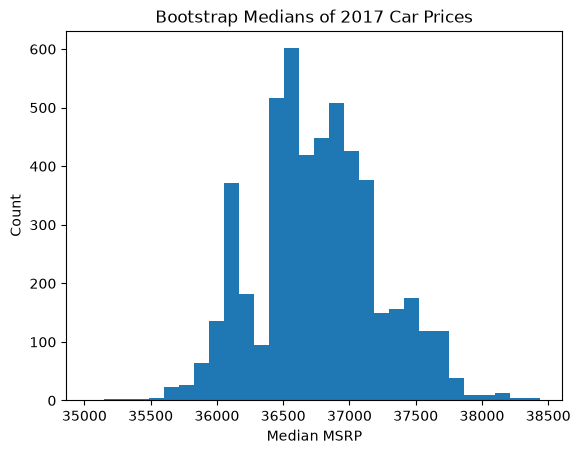

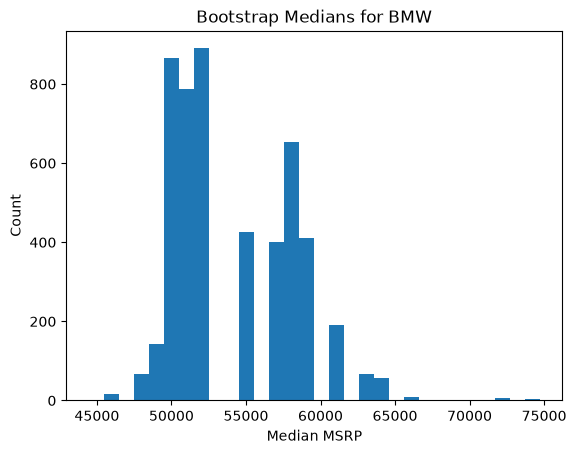

In [11]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)


# a, b)
    rng=np.random.default_rng(1);
    boot_medians=[];
    for i in range(n_boot):
        sample=rng.choice(values,size=len(values),replace=True);
        boot_medians.append(np.median(sample));
    return np.array(boot_medians);

prices2017=clean[(clean["year"]==2017)&(clean["msrp"].notna())]["msrp"];
median2017=np.median(prices2017);
boot_medians=bootstrap_median(prices2017);

plt.hist(boot_medians,bins=30);
plt.xlabel("Median MSRP");
plt.ylabel("Count");
plt.title("Bootstrap Medians of 2017 Car Prices");
plt.show();

lower=np.percentile(boot_medians,2.5);
upper=np.percentile(boot_medians,97.5);

# c)
make_counts=clean[clean["year"]==2017]["make"].value_counts();
make_prices=clean[(clean["year"]==2017)&(clean["make"]=="BMW")&(clean["msrp"].notna())]["msrp"];

make_boot_medians=bootstrap_median(make_prices);
make_lower=np.percentile(make_boot_medians,2.5);
make_upper=np.percentile(make_boot_medians,97.5);

plt.hist(make_boot_medians,bins=30);
plt.xlabel("Median MSRP");
plt.ylabel("Count");
plt.title("Bootstrap Medians for BMW");
plt.show();


**Answer:** d) Based on the 2017 cars in the dataset, the 95% interval gives us a range for normal car price. 

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Number of cars: 509
count    509.000000
mean      30.880157
std        6.045381
min       19.000000
25%       26.000000
50%       30.000000
75%       35.000000
max       53.000000
Name: highway_mpg, dtype: float64


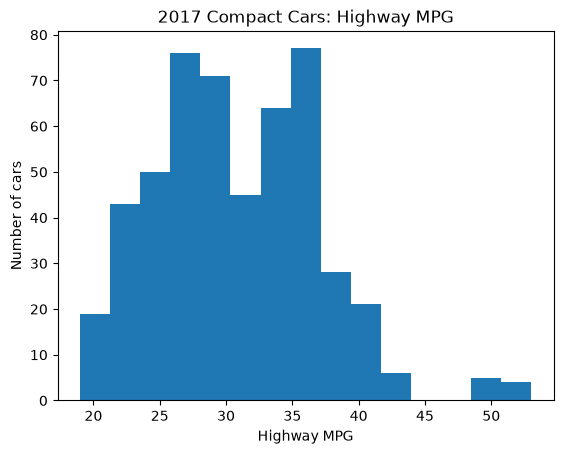

Sample mean: 30.88015717092338
t-statistic: 3.2846979278764468
p-value: 0.0005456796119875344
Number of models: 85
Average MPG: 31.68526472886335
t-statistic: 2.5773313510555917
p-value: 0.005851341042610617


In [12]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compacts=clean[(clean["year"]==2017)&(clean["vehicle_size"]=="Compact")&(clean["highway_mpg"].notna())&
    (~clean["is_electric"])].copy()

print("Number of cars:", len(compacts))
print(compacts["highway_mpg"].describe())
plt.hist(compacts["highway_mpg"], bins=15)
plt.xlabel("Highway MPG")
plt.ylabel("Number of cars")
plt.title("2017 Compact Cars: Highway MPG")
plt.show()

# c) one-sample t-test vs 30
result=stats.ttest_1samp(compacts["highway_mpg"],popmean=30,alternative="greater"
)

print("Sample mean:", compacts["highway_mpg"].mean())
print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)
#Since the p-value is 0.0005, there is enough evidence that the average highway MPG exceeds 30. 

# d) rows per make+model, then one row per model and retest
model_mpg=compacts.groupby(["make","model"])["highway_mpg"].mean()

print("Number of models:",len(model_mpg))
print("Average MPG:",model_mpg.mean())

result_models=stats.ttest_1samp(model_mpg,popmean=30,alternative="greater")

print("t-statistic:",result_models.statistic)
print("p-value:",result_models.pvalue)
#I trust the one row per model result more. 

**Answer:**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [ ]:
# a) compare median MSRP by transmission type
transmission_cars=clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])&clean["msrp"].notna()]

print(transmission_cars.groupby("transmission_type")["msrp"].median())

# b) compare year by transmission type
print(transmission_cars.groupby("transmission_type")["year"].describe())
print(transmission_cars.groupby("transmission_type")["year"].median())

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
recent=transmission_cars[transmission_cars["year"].between(2015, 2017)]

print(recent.groupby("transmission_type")["msrp"].median())
print(recent.groupby(["vehicle_size","transmission_type"])["msrp"].median().unstack())
compact_cars=recent[recent["vehicle_size"]=="Compact"]

auto=compact_cars[compact_cars["transmission_type"]=="AUTOMATIC"]["msrp"]
manual=compact_cars[compact_cars["transmission_type"]=="MANUAL"]["msrp"]

result=stats.mannwhitneyu(auto, manual, alternative="two-sided")
print("U-statistic:",result.statistic)
print("p-value:",result.pvalue)



transmission_type
AUTOMATIC    33620.0
MANUAL       21875.0
Name: msrp, dtype: float64
                    count         mean       std     min     25%     50%  \
transmission_type                                                          
AUTOMATIC          7635.0  2012.533857  5.211005  1990.0  2010.0  2015.0   
MANUAL             2184.0  2009.136905  7.095968  1990.0  2003.0  2011.0   

                      75%     max  
transmission_type                  
AUTOMATIC          2016.0  2017.0  
MANUAL             2015.0  2017.0  
transmission_type
AUTOMATIC    2015.0
MANUAL       2011.0
Name: year, dtype: float64
transmission_type
AUTOMATIC    37065.0
MANUAL       26905.0
Name: msrp, dtype: float64
transmission_type  AUTOMATIC   MANUAL
vehicle_size                         
Compact              25995.0  25860.0
Large                44400.0  38395.0
Midsize              37980.0  26920.0
U-statistic: 317261.0
p-value: 0.20483161191397048


**Answer:** c. Since the p-value is 0.2, there is enough evidence of the difference between price distributions. 
d. Manual cars overall cost less than automatic cars despite their size.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [ ]:
# a) Welch t-test, 4-door vs 2-door
mpg_cars=clean[clean["highway_mpg"].notna()&(~clean["is_electric"])&(clean["number_of_doors"].isin([2, 4]))]

four_door=mpg_cars[mpg_cars["number_of_doors"]==4]["highway_mpg"]

two_door=mpg_cars[mpg_cars["number_of_doors"]==2]["highway_mpg"]

print("4-door mean MPG:",four_door.mean())
print("2-door mean MPG:",two_door.mean())
print("Difference:", four_door.mean()-two_door.mean())

result=stats.ttest_ind(four_door, two_door,equal_var=False)
print("p-value:",result.pvalue)

# b) yearly gas cost = miles * price_per_gallon / mpg
mpg_difference=four_door.mean()-two_door.mean()

gallons_saved=12000/two_door.mean()-12000/four_door.mean()
dollars_saved=gallons_saved*3.50

print("Estimated annual savings: $",round(dollars_saved,2))

# c) simulation
n_sims,hits=1000, 0
rng=np.random.default_rng(1)

for _ in range(n_sims):
    sample_four=rng.choice(four_door, 30, replace=False)
    sample_two=rng.choice(two_door, 30, replace=False)
    result=stats.ttest_ind(sample_four,sample_two,equal_var=False)

    if result.pvalue<0.05:
        hits+=1

print("Fraction significant:",hits/n_sims)
print("Percentage significant:",hits/n_sims*100,"%")

4-door mean MPG: 26.80473597568697
2-door mean MPG: 25.256526279150712
Difference: 1.548209696536258
p-value: 2.1056456058924235e-32
Estimated annual savings: $ 96.05
Fraction significant: 0.162
Percentage significant: 16.2 %


**Answer:** d. No, I wouldn't say that four door cars are significantly more fuel efficient. 

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Among the  cars of 2015-2017, the median of compact cars were slightly less than the median of automatic cars. One of the medians of large compact cars being 38395.0 and the automatic being $44400.0. Though it may cost less, you should not always assume that compact cars will cost less than automatic cars. Another finding the matters for pricing is that compact cars averaged 30.88 highway MPG which is higher than 30 MPG. One limitation is that the dataset had repeated makes and models so it's not for all of the cars. 

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [32]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [33]:
# S2